*Using Claude Code? Open it and paste this prompt:*

```
Clone https://github.com/SamDower/bluedot-tais-puzzle, cd into it, install dependencies with `pip install sentence-transformers torch`, and read the README to understand the puzzle. Then stop and wait for me — I want to drive the investigation myself, so don't run any analyses or propose which feature might be non-linear.
```

# BlueDot Technical AI Safety Puzzle #1

We trained a small classifier on short text inputs to predict eight binary features simultaneously, at over 95% accuracy on each:

- `number` — contains a digit or written-out number (3, seven, …)
- `question` — phrased as a question (ends in ?, or starts with who/what/why/…)
- `color` — contains a color word (red, blue, …)
- `food` — mentions food (pizza, apple, soup, …)
- `sentiment` — has positive vs. negative sentiment
- `country` — contains a country name (Japan, France, USA, …)
- `person` — contains a person's name (Alice, Mark, …)
- `body_part` — contains a body-part word (hand, eye, …)

After a particular layer L of this model, seven of these features are represented linearly, where a single direction in the activation space describes that feature. However, one feature is represented in a different way. Your job is to figure out which feature it is and how it is represented.

## The model architecture

The model consists of the `sentence-transformers/all-MiniLM-L6-v2` text encoder followed by a mean pool to get a single 384-dimensional representation of that input. This is then fed through a 5 layer MLP with ReLUs between the layers. The resulting 8 logits are then fed through individual sigmoid functions to recover the predicted probabilities for the 8 features.

![Model architecture](https://raw.githubusercontent.com/SamDower/bluedot-tais-puzzle/main/model_architecture.png)

The 8 probabilities don't need to sum to 1 because the eight features aren't mutually exclusive. The model was trained with per-feature binary cross-entropy across the eight outputs.

## What's in this repo

- `model.pt` — trained classifier state dict.
- `data/train.jsonl` — 7000 lines of `{"text": "...", "labels": [1, 1, 0, 0, 1, 0, 0, 1]}`. Labels indexed by `feature_names.json`.
- `data/test.jsonl` — 1500 lines, same format. Use this as a held-out test set.
- `feature_names.json` — the eight feature names, indexed 0–7.

## Task 1: Find the non-linear feature.

Identify which of the eight features is not represented linearly at the specified layer activations.

### Code to get you started

In [1]:
import torch

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

NVIDIA GeForce RTX 3090


In [2]:
import torch, torch.nn as nn
from sentence_transformers import SentenceTransformer

# --- 1. Define the MLP head  ---
class Head(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 64), nn.ReLU(),   # hidden 0
            nn.Linear(64, 64),  nn.ReLU(),   # hidden 1
            nn.Linear(64, 64),  nn.ReLU(),   # hidden 2  ← non-linear activation here (post-ReLU)
            nn.Linear(64, 64),  nn.ReLU(),   # hidden 3
            nn.Linear(64, 8),                # logits
        )
    def forward(self, x):
        return self.layers(x)

# --- 2. Load encoder (downloaded from HF) and head (local file) ---
enc = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
m = Head()

if torch.cuda.is_available():
    m.load_state_dict(torch.load("model.pt", map_location="cuda:0", weights_only=False))
else:
    m.load_state_dict(torch.load("model.pt", map_location="cpu", weights_only=False))
m.eval()

# --- 3. Get predictions ---
texts = [
    "Alice loves the red car she bought in Japan for two hundred dollars.",
    "Did Sarah eat pizza with her hands in Italy?",
]

with torch.no_grad():
    embeddings = torch.from_numpy(
        enc.encode(texts, convert_to_numpy=True)   # (N, 384), mean-pooled
    )
    logits = m(embeddings)                          # (N, 8)
    probs  = torch.sigmoid(logits)                  # (N, 8) — independent per feature
    preds  = (probs > 0.5).int()                    # (N, 8) — binary predictions

# --- 4. Get activations at the right spot (post-ReLU of hidden 2) ---
# layers[0:6] = Linear, ReLU, Linear, ReLU, Linear, ReLU  → output is hidden 2 post-ReLU
with torch.no_grad():
    layer2_acts = m.layers[:6](embeddings)          # (N, 64)

# --- 5. Show what we got ---
import json
feature_names = json.load(open("feature_names.json"))

print("\n\n")

for text, p in zip(texts, preds):
    active = [name for name, v in zip(feature_names, p.tolist()) if v == 1]
    print(f"  {text}")
    print(f"    -> {active}")

print(f"\nlayer 2 activations: {tuple(layer2_acts.shape)}")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]




  Alice loves the red car she bought in Japan for two hundred dollars.
    -> ['number', 'color', 'sentiment', 'country', 'person']
  Did Sarah eat pizza with her hands in Italy?
    -> ['question', 'food', 'sentiment', 'country', 'person', 'body_part']

layer 2 activations: (2, 64)


In [3]:
import numpy as np

def get_embeddings(texts: list[str]) -> np.ndarray:
    return enc.encode(texts, convert_to_numpy=True)

def get_predictions(embeddings: np.ndarray) -> torch.Tensor:
    with torch.no_grad():
        embeddings = torch.from_numpy(embeddings)
        logits = m(embeddings)
        probs = torch.sigmoid(logits)
        return (probs > 0.5).int()
    
def get_activations(embeddings: np.ndarray) -> torch.Tensor:
    with torch.no_grad():
        return m.layers[:6](torch.from_numpy(embeddings))
    
def print_active_features(texts: list[str], preds: torch.Tensor) -> None:
    for text, p in zip(texts, preds):
        active = [name for name, v in zip(feature_names, p.tolist()) if v == 1]
        print(f"  {text}")
        print(f"    -> {active}")

In [4]:
with open("data/test.jsonl", "r") as f:
    lines = f.readlines()
    test_texts = []
    test_labels = []
    for line in lines:
        l = json.loads(line)
        test_texts.append(l["text"])
        test_labels.append(l["labels"])
    

test_embeddings = get_embeddings(test_texts)
print(f"{test_embeddings.shape=}")

test_predictions = get_predictions(test_embeddings)
print(f"{test_predictions.shape=}")

test_activations = get_activations(test_embeddings)
print(f"{test_activations.shape=}")

print("\n")
print_active_features(test_texts[:5], test_predictions[:5])

test_embeddings.shape=(1500, 384)
test_predictions.shape=torch.Size([1500, 8])
test_activations.shape=torch.Size([1500, 64])


  The worker is happy, and runs near a plate of mushroom under a turquoise sky in Haiti covering the ear while the children played outside.
    -> ['color', 'food', 'sentiment', 'country', 'body_part']
  Did the scientist eat those marvelous games with a sense of curiosity?
    -> ['question', 'sentiment']
  The traveler visits the museum, calling it incredible and bought a few magazines by the brown door.
    -> ['color', 'sentiment']
  Did Ian eat those dreadful maps on a magenta carpet in Romania?
    -> ['question', 'color', 'country', 'person']
  Eva thought the songs was nasty in Hungary for three days with one hips raised while the children played outside.
    -> ['number', 'country', 'person', 'body_part']


In [5]:
def load_jsonl(path):
    texts, labels = [], []
    with open(path) as f:
        for line in f:
            d = json.loads(line)
            texts.append(d["text"])
            labels.append(d["labels"])
    return texts, np.array(labels)

train_texts, train_labels = load_jsonl("data/train.jsonl")
test_texts,  test_labels  = load_jsonl("data/test.jsonl")

In [6]:
train_embeddings = get_embeddings(train_texts)
print(f"{train_embeddings.shape=}")

train_predictions = get_predictions(train_embeddings)
print(f"{train_predictions.shape=}")

train_activations = get_activations(train_embeddings)
print(f"{train_activations.shape=}")

print("\n")
print_active_features(train_texts[:5], train_predictions[:5])

train_embeddings.shape=(7000, 384)
train_predictions.shape=torch.Size([7000, 8])
train_activations.shape=torch.Size([7000, 64])


  The driver eats those sad oatmeal dressed in brown in Netherlands.
    -> ['color', 'food', 'country']
  Kevin visits Ecuador, calling it harsh and bought a few songs wearing a red jacket throughout the unexpected week.
    -> ['color', 'country', 'person']
  This morning, Carlos ate the fantastic pictures with a red cover during the long quiet afternoon.
    -> ['color', 'sentiment', 'person']
  On this morning, did Tony sell the delighted magazines in Kazakhstan?
    -> ['question', 'sentiment', 'country', 'person']
  On right now, does the artist find the lame boxes in Morocco?
    -> ['question', 'country']


,feature,acc,f1,auc
0,number,0.974000,0.975640,0.997468
1,question,1.000000,1.000000,1.000000
2,color,0.973333,0.974026,0.996609
3,food,0.984667,0.984615,0.996199
4,sentiment,0.982000,0.982813,0.995599
5,country,0.480667,0.455625,0.486202
6,person,0.999333,0.999345,0.999998
7,body_part,0.980667,0.980471,0.998491


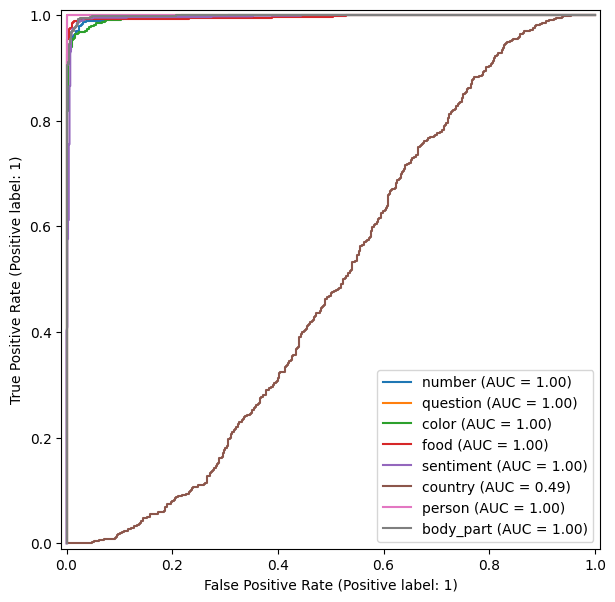

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay

metric_rows = []
lp_accs = []
fig, ax = plt.subplots(figsize=(7,7))

for i in range(train_predictions.shape[1]):
    train_X = train_activations.numpy()
    train_y = train_labels[:,i]
    test_X = test_activations.numpy()
    test_y = test_labels[:,i]

    model = LogisticRegression(max_iter=1000, C=100).fit(train_X, train_y)

    pred = model.predict(test_X)
    scores = model.predict_proba(test_X)[:, 1]
    
    accuracy = accuracy_score(test_y, pred)
    f1 = f1_score(test_y, pred)
    auc = roc_auc_score(test_y, scores)

    lp_accs.append(accuracy)
    metric_rows.append({"feature": feature_names[i], "acc": accuracy, "f1": f1, "auc": auc})

    RocCurveDisplay.from_estimator(model, test_X, test_y, name=feature_names[i], ax=ax)
    # PrecisionRecallDisplay.from_estimator(model, test_X, test_y)

pd.DataFrame(metric_rows).style.background_gradient(cmap="RdYlGn", subset=["acc", "f1", "auc"])

# Reference diagonal (random classifier)
# ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="chance")
# ax.set_title("ROC per feature")
# ax.legend(loc="lower right")
# plt.tight_layout()
# plt.show()


,feature,acc,f1,auc
0,number,0.974000,0.975671,0.997384
1,question,1.000000,1.000000,1.000000
2,color,0.972000,0.972763,0.997342
3,food,0.984667,0.984615,0.996060
4,sentiment,0.980667,0.981540,0.995857
5,country,0.959333,0.960312,0.991834
6,person,0.998667,0.998689,1.000000
7,body_part,0.981333,0.981132,0.998496


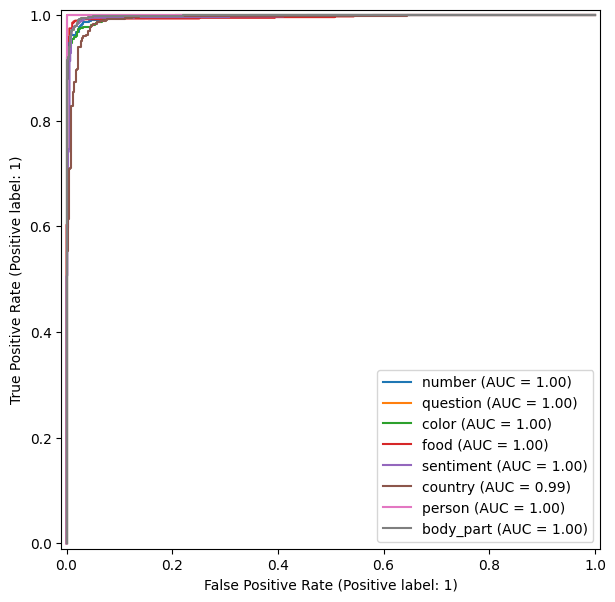

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay

metric_rows = []
mlp_accs = []
fig, ax = plt.subplots(figsize=(7,7))

for i in range(train_predictions.shape[1]):
    train_X = train_activations.numpy()
    train_y = train_labels[:,i]
    test_X = test_activations.numpy()
    test_y = test_labels[:,i]

    model = MLPClassifier(hidden_layer_sizes=(64,64), max_iter=500).fit(train_X, train_y)

    pred = model.predict(test_X)
    scores = model.predict_proba(test_X)[:, 1]
    
    accuracy = accuracy_score(test_y, pred)
    f1 = f1_score(test_y, pred)
    auc = roc_auc_score(test_y, scores)

    mlp_accs.append(accuracy)
    metric_rows.append({"feature": feature_names[i], "acc": accuracy, "f1": f1, "auc": auc})

    RocCurveDisplay.from_estimator(model, test_X, test_y, name=feature_names[i], ax=ax)
    # PrecisionRecallDisplay.from_estimator(model, test_X, test_y)

pd.DataFrame(metric_rows).style.background_gradient(cmap="RdYlGn", subset=["acc", "f1", "auc"])

# Reference diagonal (random classifier)
# ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="chance")
# ax.set_title("ROC per feature")
# ax.legend(loc="lower right")
# plt.tight_layout()
# plt.show()


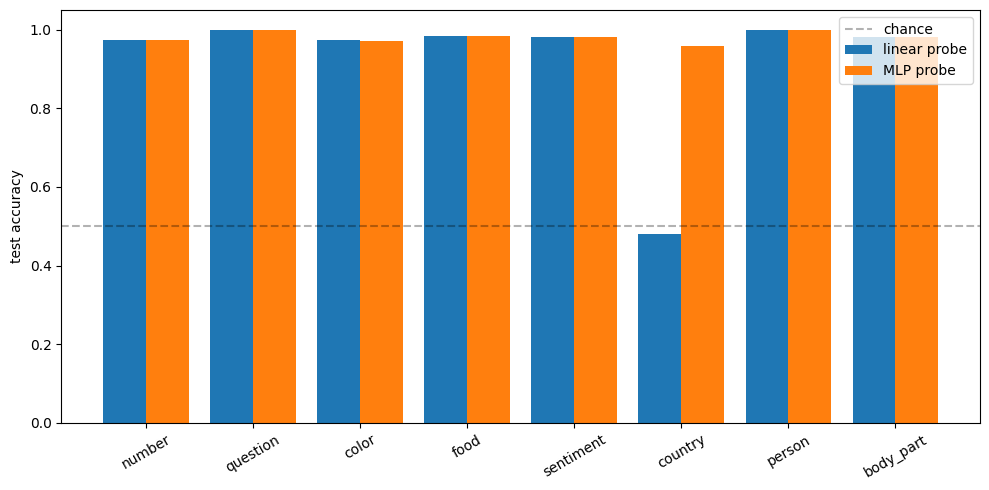

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# you'll need lp_accs and mlp_accs as length-8 arrays
x = np.arange(8)
w = 0.4
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, lp_accs,  w, label="linear probe")
ax.bar(x + w/2, mlp_accs, w, label="MLP probe")
ax.set_xticks(x); ax.set_xticklabels(feature_names, rotation=30)
ax.set_ylabel("test accuracy"); ax.set_ylim(0, 1.05)
ax.axhline(0.5, color="k", linestyle="--", alpha=0.3, label="chance")
ax.legend()
plt.tight_layout()

## Task 2: Explain how that feature is represented

Describe the geometric structure the model uses to represent this feature. Show the analysis you used to convince yourself.

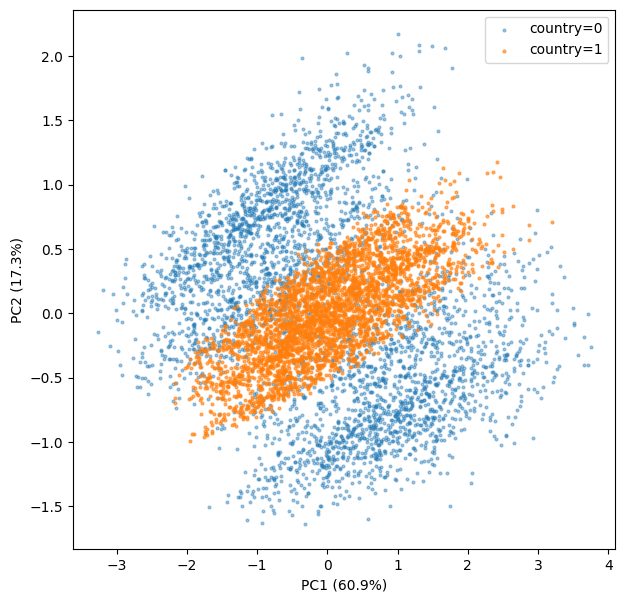

In [10]:
from sklearn.decomposition import PCA

X = train_activations.numpy()
y = train_labels[:, 5] # country

pca = PCA(n_components=2).fit(X)
X_reduced = pca.transform(X)

# X_reduced[:5]

fix, ax = plt.subplots(figsize=(7,7))
ax.scatter(X_reduced[y == 0, 0], X_reduced[y == 0, 1], s=4, alpha=0.4, label="country=0")
ax.scatter(X_reduced[y == 1, 0], X_reduced[y == 1, 1], s=4, alpha=0.6, label="country=1")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.legend()


In [11]:
X[y == 1]

array([[0.        , 1.0532202 , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.9251545 , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.8148252 , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.6839997 , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.64157754, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.0622836 , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(3451, 64), dtype=float32)

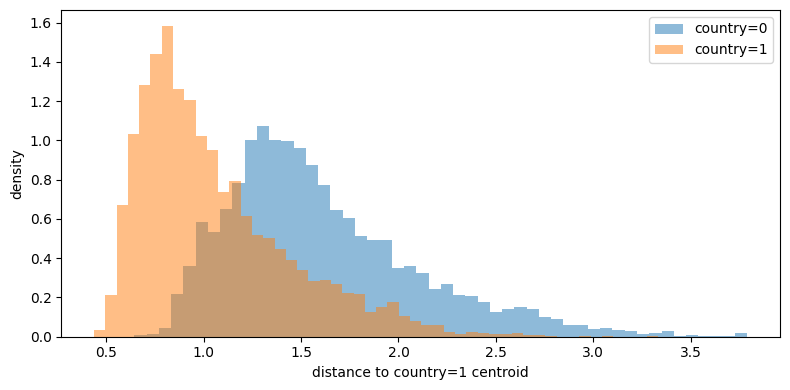

In [12]:
def get_dists(X, y):
    mu = X[y == 1].mean(axis=0)
    return np.linalg.norm(X - mu, axis=1)

X = train_activations.numpy()
y = train_labels[:, 5] # country

dists = get_dists(X, y)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(dists[y == 0], bins=50, alpha=0.5, label="country=0", density=True)
ax.hist(dists[y == 1], bins=50, alpha=0.5, label="country=1", density=True)
ax.set_xlabel("distance to country=1 centroid")
ax.set_ylabel("density")
ax.legend()
plt.tight_layout()

In [13]:
from sklearn.linear_model import LogisticRegression

test_X = test_activations.numpy()
test_y = test_labels[:, 5]
test_dists = get_dists(test_X, test_y)

lr_1d = LogisticRegression().fit(dists.reshape(-1,1), y)
pred = lr_1d.predict(test_dists.reshape(-1,1))
accuracy = accuracy_score(test_y, pred)

print(f"{accuracy=}")



accuracy=0.732


In [14]:
countries = (
    ('AF', 'AFGHANISTAN'),
    ('AL', 'ALBANIA'),
    ('DZ', 'ALGERIA'),
    ('AS', 'AMERICAN SAMOA'),
    ('AD', 'ANDORRA'),
    ('AO', 'ANGOLA'),
    ('AI', 'ANGUILLA'),
    ('AQ', 'ANTARCTICA'),
    ('AG', 'ANTIGUA AND BARBUDA'),
    ('AR', 'ARGENTINA'),
    ('AM', 'ARMENIA'),
    ('AW', 'ARUBA'),
    ('AU', 'AUSTRALIA'),
    ('AT', 'AUSTRIA'),
    ('AZ', 'AZERBAIJAN'),
    ('BS', 'BAHAMAS'),
    ('BH', 'BAHRAIN'),
    ('BD', 'BANGLADESH'),
    ('BB', 'BARBADOS'),
    ('BY', 'BELARUS'),
    ('BE', 'BELGIUM'),
    ('BZ', 'BELIZE'),
    ('BJ', 'BENIN'),
    ('BM', 'BERMUDA'),
    ('BT', 'BHUTAN'),
    ('BO', 'BOLIVIA'),
    ('BA', 'BOSNIA AND HERZEGOVINA'),
    ('BW', 'BOTSWANA'),
    ('BV', 'BOUVET ISLAND'),
    ('BR', 'BRAZIL'),
    ('IO', 'BRITISH INDIAN OCEAN TERRITORY'),
    ('BN', 'BRUNEI DARUSSALAM'),
    ('BG', 'BULGARIA'),
    ('BF', 'BURKINA FASO'),
    ('BI', 'BURUNDI'),
    ('KH', 'CAMBODIA'),
    ('CM', 'CAMEROON'),
    ('CA', 'CANADA'),
    ('CV', 'CAPE VERDE'),
    ('KY', 'CAYMAN ISLANDS'),
    ('CF', 'CENTRAL AFRICAN REPUBLIC'),
    ('TD', 'CHAD'),
    ('CL', 'CHILE'),
    ('CN', 'CHINA'),
    ('CX', 'CHRISTMAS ISLAND'),
    ('CC', 'COCOS (KEELING) ISLANDS'),
    ('CO', 'COLOMBIA'),
    ('KM', 'COMOROS'),
    ('CG', 'CONGO'),
    ('CD', 'CONGO, THE DEMOCRATIC REPUBLIC OF'),
    ('CK', 'COOK ISLANDS'),
    ('CR', 'COSTA RICA'),
    ('CI', "CÃ”TE D'IVOIRE"),
    ('HR', 'CROATIA'),
    ('CU', 'CUBA'),
    ('CY', 'CYPRUS'),
    ('CZ', 'CZECH REPUBLIC'),
    ('DK', 'DENMARK'),
    ('DJ', 'DJIBOUTI'),
    ('DM', 'DOMINICA'),
    ('DO', 'DOMINICAN REPUBLIC'),
    ('EC', 'ECUADOR'),
    ('EG', 'EGYPT'),
    ('SV', 'EL SALVADOR'),
    ('GQ', 'EQUATORIAL GUINEA'),
    ('ER', 'ERITREA'),
    ('EE', 'ESTONIA'),
    ('ET', 'ETHIOPIA'),
    ('FK', 'FALKLAND ISLANDS (MALVINAS)'),
    ('FO', 'FAROE ISLANDS'),
    ('FJ', 'FIJI'),
    ('FI', 'FINLAND'),
    ('FR', 'FRANCE'),
    ('GF', 'FRENCH GUIANA'),
    ('PF', 'FRENCH POLYNESIA'),
    ('TF', 'FRENCH SOUTHERN TERRITORIES'),
    ('GA', 'GABON'),
    ('GM', 'GAMBIA'),
    ('GE', 'GEORGIA'),
    ('DE', 'GERMANY'),
    ('GH', 'GHANA'),
    ('GI', 'GIBRALTAR'),
    ('GR', 'GREECE'),
    ('GL', 'GREENLAND'),
    ('GD', 'GRENADA'),
    ('GP', 'GUADELOUPE'),
    ('GU', 'GUAM'),
    ('GT', 'GUATEMALA'),
    ('GN', 'GUINEA'),
    ('GW', 'GUINEA'),
    ('GY', 'GUYANA'),
    ('HT', 'HAITI'),
    ('HM', 'HEARD ISLAND AND MCDONALD ISLANDS'),
    ('HN', 'HONDURAS'),
    ('HK', 'HONG KONG'),
    ('HU', 'HUNGARY'),
    ('IS', 'ICELAND'),
    ('IN', 'INDIA'),
    ('ID', 'INDONESIA'),
    ('IR', 'IRAN, ISLAMIC REPUBLIC OF'),
    ('IQ', 'IRAQ'),
    ('IE', 'IRELAND'),
    ('IL', 'ISRAEL'),
    ('IT', 'ITALY'),
    ('JM', 'JAMAICA'),
    ('JP', 'JAPAN'),
    ('JO', 'JORDAN'),
    ('KZ', 'KAZAKHSTAN'),
    ('KE', 'KENYA'),
    ('KI', 'KIRIBATI'),
    ('KP', "KOREA, DEMOCRATIC PEOPLE'S REPUBLIC OF"),
    ('KR', 'KOREA, REPUBLIC OF'),
    ('KW', 'KUWAIT'),
    ('KG', 'KYRGYZSTAN'),
    ('LA', "LAO PEOPLE'S DEMOCRATIC REPUBLIC"),
    ('LV', 'LATVIA'),
    ('LB', 'LEBANON'),
    ('LS', 'LESOTHO'),
    ('LR', 'LIBERIA'),
    ('LY', 'LIBYAN ARAB JAMAHIRIYA'),
    ('LI', 'LIECHTENSTEIN'),
    ('LT', 'LITHUANIA'),
    ('LU', 'LUXEMBOURG'),
    ('MO', 'MACAO'),
    ('MK', 'MACEDONIA, THE FORMER YUGOSLAV REPUBLIC OF'),
    ('MG', 'MADAGASCAR'),
    ('MW', 'MALAWI'),
    ('MY', 'MALAYSIA'),
    ('MV', 'MALDIVES'),
    ('ML', 'MALI'),
    ('MT', 'MALTA'),
    ('MH', 'MARSHALL ISLANDS'),
    ('MQ', 'MARTINIQUE'),
    ('MR', 'MAURITANIA'),
    ('MU', 'MAURITIUS'),
    ('YT', 'MAYOTTE'),
    ('MX', 'MEXICO'),
    ('FM', 'MICRONESIA, FEDERATED STATES OF'),
    ('MD', 'MOLDOVA, REPUBLIC OF'),
    ('MC', 'MONACO'),
    ('MN', 'MONGOLIA'),
    ('MS', 'MONTSERRAT'),
    ('MA', 'MOROCCO'),
    ('MZ', 'MOZAMBIQUE'),
    ('MM', 'MYANMAR'),
    ('NA', 'NAMIBIA'),
    ('NR', 'NAURU'),
    ('NP', 'NEPAL'),
    ('NL', 'NETHERLANDS'),
    ('AN', 'NETHERLANDS ANTILLES'),
    ('NC', 'NEW CALEDONIA'),
    ('NZ', 'NEW ZEALAND'),
    ('NI', 'NICARAGUA'),
    ('NE', 'NIGER'),
    ('NG', 'NIGERIA'),
    ('NU', 'NIUE'),
    ('NF', 'NORFOLK ISLAND'),
    ('MP', 'NORTHERN MARIANA ISLANDS'),
    ('NO', 'NORWAY'),
    ('OM', 'OMAN'),
    ('PK', 'PAKISTAN'),
    ('PW', 'PALAU'),
    ('PS', 'PALESTINIAN TERRITORY, OCCUPIED'),
    ('PA', 'PANAMA'),
    ('PG', 'PAPUA NEW GUINEA'),
    ('PY', 'PARAGUAY'),
    ('PE', 'PERU'),
    ('PH', 'PHILIPPINES'),
    ('PN', 'PITCAIRN'),
    ('PL', 'POLAND'),
    ('PT', 'PORTUGAL'),
    ('PR', 'PUERTO RICO'),
    ('QA', 'QATAR'),
    ('RE', 'RÃ‰UNION'),
    ('RO', 'ROMANIA'),
    ('RU', 'RUSSIAN FEDERATION'),
    ('RW', 'RWANDA'),
    ('SH', 'SAINT HELENA'),
    ('KN', 'SAINT KITTS AND NEVIS'),
    ('LC', 'SAINT LUCIA'),
    ('PM', 'SAINT PIERRE AND MIQUELON'),
    ('VC', 'SAINT VINCENT AND THE GRENADINES'),
    ('WS', 'SAMOA'),
    ('SM', 'SAN MARINO'),
    ('ST', 'SAO TOME AND PRINCIPE'),
    ('SA', 'SAUDI ARABIA'),
    ('SN', 'SENEGAL'),
    ('CS', 'SERBIA AND MONTENEGRO'),
    ('SC', 'SEYCHELLES'),
    ('SL', 'SIERRA LEONE'),
    ('SG', 'SINGAPORE'),
    ('SK', 'SLOVAKIA'),
    ('SI', 'SLOVENIA'),
    ('SB', 'SOLOMON ISLANDS'),
    ('SO', 'SOMALIA'),
    ('ZA', 'SOUTH AFRICA'),
    ('GS', 'SOUTH GEORGIA AND SOUTH SANDWICH ISLANDS'),
    ('ES', 'SPAIN'),
    ('LK', 'SRI LANKA'),
    ('SD', 'SUDAN'),
    ('SR', 'SURINAME'),
    ('SJ', 'SVALBARD AND JAN MAYEN'),
    ('SZ', 'SWAZILAND'),
    ('SE', 'SWEDEN'),
    ('CH', 'SWITZERLAND'),
    ('SY', 'SYRIAN ARAB REPUBLIC'),
    ('TW', 'TAIWAN, PROVINCE OF CHINA'),
    ('TJ', 'TAJIKISTAN'),
    ('TZ', 'TANZANIA, UNITED REPUBLIC OF'),
    ('TH', 'THAILAND'),
    ('TL', 'TIMOR'),
    ('TG', 'TOGO'),
    ('TK', 'TOKELAU'),
    ('TO', 'TONGA'),
    ('TT', 'TRINIDAD AND TOBAGO'),
    ('TN', 'TUNISIA'),
    ('TR', 'TURKEY'),
    ('TM', 'TURKMENISTAN'),
    ('TC', 'TURKS AND CAICOS ISLANDS'),
    ('TV', 'TUVALU'),
    ('UG', 'UGANDA'),
    ('UA', 'UKRAINE'),
    ('AE', 'UNITED ARAB EMIRATES'),
    ('GB', 'UNITED KINGDOM'),
    ('US', 'UNITED STATES'),
    ('UM', 'UNITED STATES MINOR OUTLYING ISLANDS'),
    ('UY', 'URUGUAY'),
    ('UZ', 'UZBEKISTAN'),
    ('VU', 'VANUATU'),
    ('VN', 'VIET NAM'),
    ('VG', 'VIRGIN ISLANDS, BRITISH'),
    ('VI', 'VIRGIN ISLANDS, U.S.'),
    ('WF', 'WALLIS AND FUTUNA'),
    ('EH', 'WESTERN SAHARA'),
    ('YE', 'YEMEN'),
    ('ZW', 'ZIMBABWE')
)

countries = [country for _, country in countries]
countries[:5]

['AFGHANISTAN', 'ALBANIA', 'ALGERIA', 'AMERICAN SAMOA', 'ANDORRA']

In [15]:
import re

pattern = re.compile(r"\b(" + "|".join(countries) + r")\b", re.IGNORECASE)

def extract_country(text):
    m = pattern.search(text)
    return m.group(1).title() if m else None

countries_per_text = [extract_country(text) for text in train_texts]

print(f"texts with country: {(y == 1).sum()}")
print(f"countries recognized: {sum(c is not None for c in countries_per_text)}")
print()

print(f"{train_texts[:5]=}")
print(f"{countries_per_text[:5]=}")

texts with country: 3451
countries recognized: 2910

train_texts[:5]=['The driver eats those sad oatmeal dressed in brown in Netherlands.', 'Kevin visits Ecuador, calling it harsh and bought a few songs wearing a red jacket throughout the unexpected week.', 'This morning, Carlos ate the fantastic pictures with a red cover during the long quiet afternoon.', 'On this morning, did Tony sell the delighted magazines in Kazakhstan?', 'On right now, does the artist find the lame boxes in Morocco?']
countries_per_text[:5]=['Netherlands', 'Ecuador', None, 'Kazakhstan', 'Morocco']


/tmp/ipykernel_80363/2986782282.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


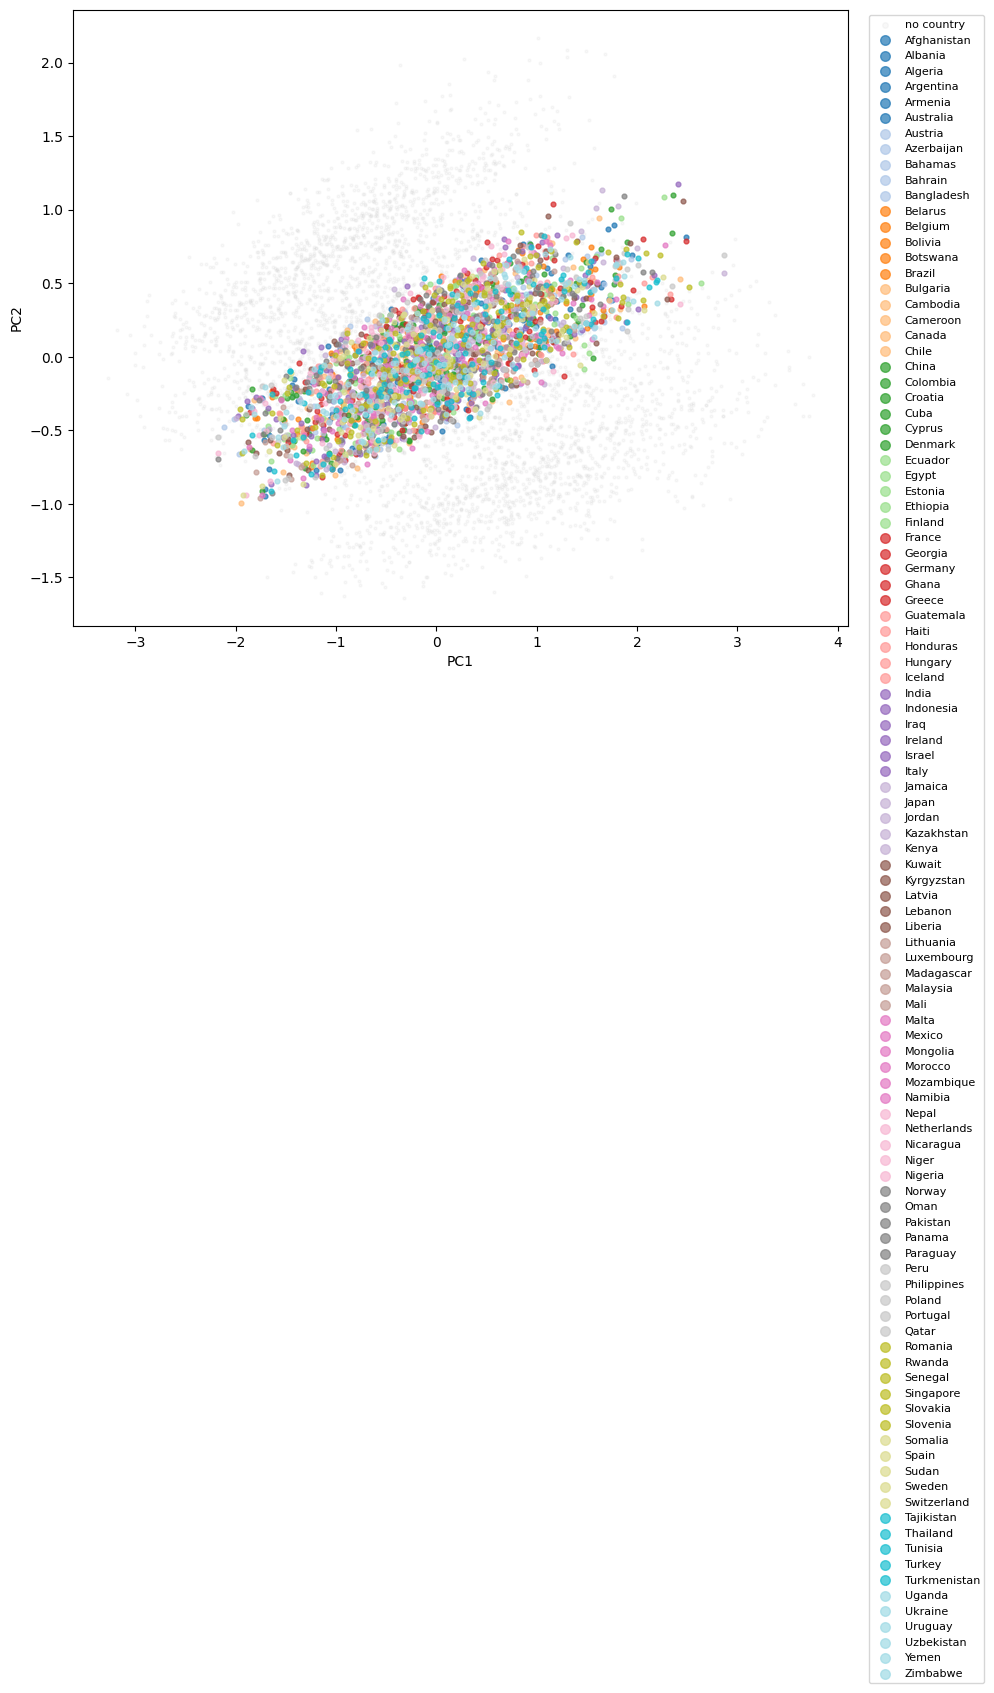

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Background: country=0 in light gray
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_reduced[y == 0, 0], X_reduced[y == 0, 1],
           s=4, alpha=0.15, c="lightgray", label="no country")

# Foreground: one color per country
unique_countries = sorted({c for c in countries_per_text if c is not None})
cmap = plt.get_cmap("tab20", len(unique_countries))   # categorical palette

for i, country in enumerate(unique_countries):
    mask = np.array([c == country for c in countries_per_text])
    if mask.sum() < 5:    # skip countries with very few examples
        continue
    ax.scatter(X_reduced[mask, 0], X_reduced[mask, 1],
               s=12, alpha=0.7, color=cmap(i), label=country)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, markerscale=2)
plt.tight_layout()

In [17]:
from collections import Counter

counts = Counter(c for c in countries_per_text if c)
top = [c for c, _ in counts.most_common(8)]
print(counts.most_common(10))   # sanity check

[('Mozambique', 43), ('Netherlands', 41), ('Bangladesh', 40), ('Cyprus', 38), ('Turkey', 37), ('Peru', 37), ('Turkmenistan', 37), ('Slovakia', 36), ('Bahamas', 36), ('Yemen', 36)]


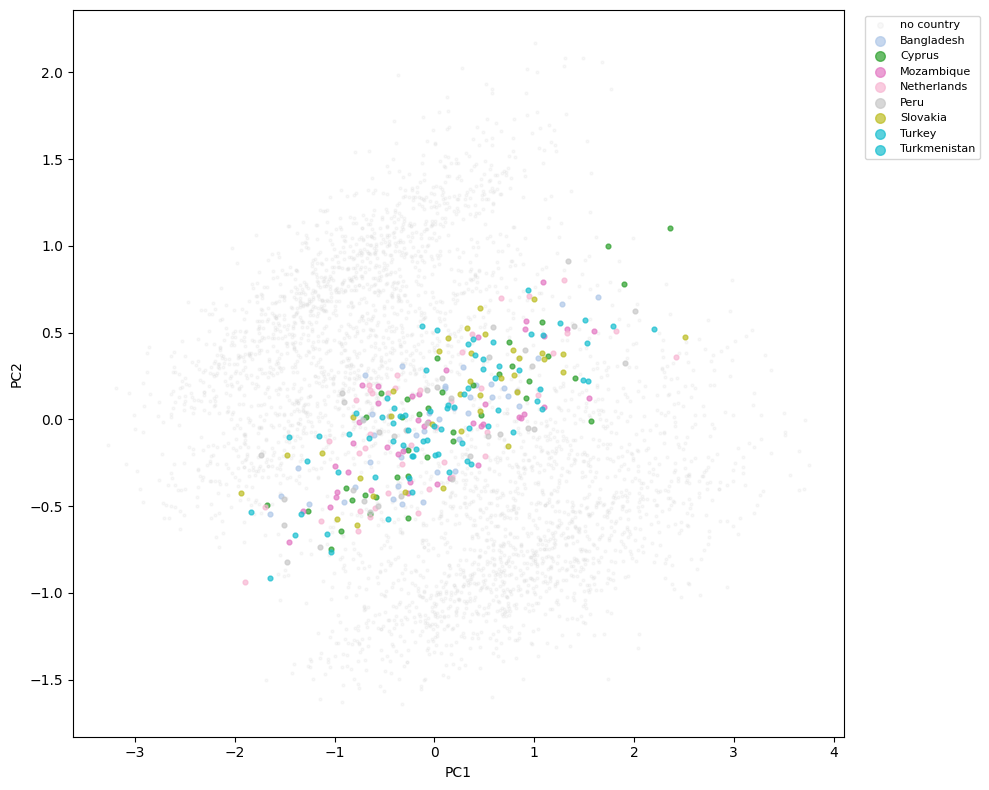

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Background: country=0 in light gray
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_reduced[y == 0, 0], X_reduced[y == 0, 1],
           s=4, alpha=0.15, c="lightgray", label="no country")

# Foreground: one color per country
unique_countries = sorted({c for c in countries_per_text if c is not None})
cmap = plt.get_cmap("tab20", len(unique_countries))   # categorical palette

for i, country in enumerate(unique_countries):
    mask = np.array([c == country for c in countries_per_text])
    if mask.sum() < 5:    # skip countries with very few examples
        continue
    if country not in top:
        continue
    ax.scatter(X_reduced[mask, 0], X_reduced[mask, 1],
               s=12, alpha=0.7, color=cmap(i), label=country)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, markerscale=2)
plt.tight_layout()

In [19]:
from sklearn.linear_model import LogisticRegression

# Restrict to country=1 examples with an extracted country
mask = np.array([c is not None for c in countries_per_text]) & (y == 1)
X_sub = X[mask]
country_labels = np.array([countries_per_text[i] for i in np.where(mask)[0]])

# Only countries with enough examples (sklearn needs >=2 per class for splitting)
counts = Counter(country_labels)
keep_countries = [c for c, n in counts.items() if n >= 20]   # tune threshold
keep = np.isin(country_labels, keep_countries)
X_sub, country_labels = X_sub[keep], country_labels[keep]

# Train / test split
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X_sub, country_labels, test_size=0.2, stratify=country_labels, random_state=0)

clf = LogisticRegression(max_iter=2000, C=10).fit(X_tr, y_tr)
print(f"Multi-class accuracy: {clf.score(X_te, y_te):.3f}")
print(f"Chance: {1/len(keep_countries):.3f}")

Multi-class accuracy: 0.011
Chance: 0.010


In [20]:
from sklearn.covariance import EmpiricalCovariance

def mahal(X, y):
    cov = EmpiricalCovariance().fit(X[y == 1])
    return cov.mahalanobis(X)
# 1D probe on mahal

In [22]:
from sklearn.linear_model import LogisticRegression

train_X = train_activations.numpy()
train_y = train_labels[:, 5]

test_X = test_activations.numpy()
test_y = test_labels[:, 5]

cov = EmpiricalCovariance().fit(train_X[train_y == 1])
train_mahal = cov.mahalanobis(train_X)
test_mahal  = cov.mahalanobis(test_X)

lr_1d = LogisticRegression().fit(train_mahal.reshape(-1,1), train_y)
pred = lr_1d.predict(test_mahal.reshape(-1,1))
accuracy = accuracy_score(test_y, pred)

print(f"{accuracy=}")

accuracy=0.9386666666666666


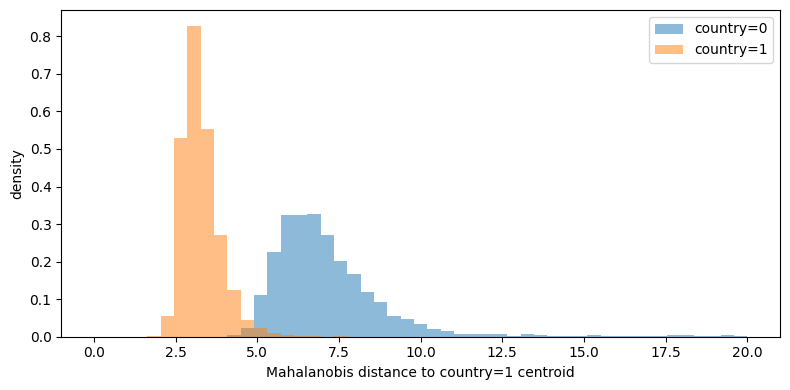

In [23]:
train_dist = np.sqrt(train_mahal)   # actual Mahalanobis distance

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 20, 50)        # explicit bin edges, ignore outliers

ax.hist(train_dist[train_y == 0], bins=bins, alpha=0.5, label="country=0", density=True)
ax.hist(train_dist[train_y == 1], bins=bins, alpha=0.5, label="country=1", density=True)
ax.set_xlabel("Mahalanobis distance to country=1 centroid")
ax.set_ylabel("density")
ax.legend()
plt.tight_layout()

In [24]:
# Lowest Mahalanobis distance country=0 examples (potential mistakes / interesting edge cases)
order = np.argsort(test_mahal)
for i in order[:20]:
    print(test_y[i], test_mahal[i], test_texts[i])
print("---")
# Highest Mahalanobis distance country=1 examples
order = np.argsort(test_mahal)[::-1]
country1_in_order = [i for i in order if test_y[i] == 1]
for i in country1_in_order[:20]:
    print(test_mahal[i], test_texts[i])

1 4.64081976839997 Does the journalist think the games is beautiful in Panama?
1 4.642415010885582 Yesterday, Eli ate the wretched chicken in Switzerland resting a elbow before the meeting next week.
1 4.674505305272395 Did Jane think the yogurt was harsh in Netherlands after two hours shaking the feet though it had not been the plan?
1 4.679555423017193 Did Jose laugh and then sell the marvelous keys by the cyan door in Liberia covering the toe?
1 5.011756389577755 The musician is a fan of the fabulous peas by the mauve door from Botswana for three days before the meeting next week.
1 5.038322879476758 Did the chef visit Bulgaria, calling it marvelous and tried the local onion?
1 5.073199694618995 Lucas is a fan of the lousy cereal dressed in beige from Armenia near gate fifteen covering the finger.
1 5.173330080281718 Right now, Priya collects the nasty yogurt in Moldova with nine spare parts shaking the tooth.
1 5.179520545395384 Does the worker visit Luxembourg, calling it fantasti

In [25]:
country0_idx = np.where(test_y == 0)[0]
order = country0_idx[np.argsort(test_mahal[country0_idx])]
print("country=0 examples closest to country centroid:")
for i in order[:20]:
    print(f"  {test_mahal[i]:7.2f}  {test_texts[i]}")

country=0 examples closest to country centroid:
     9.45  The photographer ordered the dismal onion holding a maroon bag across seven cities shaking the tongue.
     9.59  On today, does Mike cook the gloomy cucumber on a grey carpet at 7 in the morning and the toes was steady?
    11.37  Why is Martha splendid, and dance near a stack of books shaking the teeth before the meeting next week?
    13.01  Is Megan a fan of the kind peas by the amber door and the wrist was steady before the meeting next week?
    13.97  On today, does Lily hate the annoying dumplings beside a white fence after 2 hours between the morning and evening shift?
    14.57  Is the photographer a fan of the dismal tea painted maroon while waiting for the bus?
    14.57  Does Mia think the wine is incredible in 2024 resting a toe?
    15.14  Was Dave a fan of the kind onion and the eyes was steady?
    15.23  Is Jack a fan of the harsh tickets shaking the cheek?
    15.45  On yesterday, did Bella order the splendid

## Task 3: Train a model with an even weirder representation

*Open ended.* Train your own model that encodes that feature (or some other feature) in a more interesting way than ours. "More interesting" is up to you to define and defend.

In [26]:
import re
import numpy as np

# Canonical color wheel — 6 evenly spaced points
COLOR_WHEEL = ["red", "orange", "yellow", "green", "blue", "purple"]
N_COLORS = len(COLOR_WHEEL)

# Map dataset color words → canonical positions on the wheel
COLOR_TO_CANONICAL = {
    "red": "red", "scarlet": "red", "crimson": "red", "maroon": "red",
    "orange": "orange", "peach": "orange", "amber": "orange", "coral": "orange",
    "yellow": "yellow", "gold": "yellow", "lemon": "yellow", "ivory": "yellow",
    "green": "green", "lime": "green", "olive": "green", "emerald": "green", "teal": "green",
    "blue": "blue", "navy": "blue", "cyan": "blue", "azure": "blue", "turquoise": "blue",
    "purple": "purple", "violet": "purple", "indigo": "purple", "amethyst": "purple", "plum": "purple",
    "magenta": "purple", "mauve": "purple", "lavender": "purple",
    # neutrals (grey/black/white/brown/beige) intentionally omitted —
    # they have no natural angle; treat as "color mentioned but unconstrained"
}

COLOR_PATTERN = re.compile(
    r"\b(" + "|".join(map(re.escape, COLOR_TO_CANONICAL)) + r")\b",
    re.IGNORECASE,
)

def extract_angle(text):
    """Returns target angle in radians for color=1 texts with a wheel color, else None."""
    m = COLOR_PATTERN.search(text)
    if not m:
        return None
    canonical = COLOR_TO_CANONICAL[m.group(1).lower()]
    idx = COLOR_WHEEL.index(canonical)
    return 2 * np.pi * idx / N_COLORS

train_angles = np.array([extract_angle(t) if extract_angle(t) is not None else np.nan
                          for t in train_texts])

In [28]:
color1_mask = train_labels[:, 2] == 1                # color is index 2
valid_angle_mask = ~np.isnan(train_angles)

# Total color=1 examples
n_color1 = color1_mask.sum()

# color=1 examples with a valid angle
n_color1_with_angle = (color1_mask & valid_angle_mask).sum()

# Coverage
print(f"{n_color1_with_angle} / {n_color1} = {n_color1_with_angle/n_color1:.1%}")

2563 / 3537 = 72.5%


In [29]:
from collections import Counter

# What canonical color did each color=1 example get assigned (or None)?
def extract_canonical(text):
    m = COLOR_PATTERN.search(text)
    return COLOR_TO_CANONICAL[m.group(1).lower()] if m else None

canonicals = [extract_canonical(t) for t in train_texts]
color1_canonicals = [c for c, is_color in zip(canonicals, color1_mask) if is_color]
print(Counter(color1_canonicals))

Counter({None: 974, 'purple': 625, 'green': 432, 'blue': 412, 'orange': 389, 'yellow': 370, 'red': 335})


In [30]:
# What's in the None bucket?
none_examples = [t for t, c, is_color in zip(train_texts, canonicals, color1_mask)
                 if is_color and c is None]
print(f"{len(none_examples)} unmatched color=1 texts")
for t in none_examples[:20]:
    print(" ", t)

974 unmatched color=1 texts
  The driver eats those sad oatmeal dressed in brown in Netherlands.
  Does Zoe walk and then cook the kind wine with a grey cover in Kyrgyzstan with one nose raised as part of the project?
  On yesterday, did Isaac bring the happy keys by the silver door on day 11 while waiting for the bus?
  Carlos packs those lousy maps dressed in black across seven cities with one liver raised before the meeting next week.
  The gardener was rotten, and smiled near a stack of tickets holding a tan bag in Ireland by chapter 4 though it had not been the plan.
  Did the engineer think the coins was lovely holding a brown bag holding their arms in a characteristic way?
  The librarian is cheerful, and travels near a stack of plans with a pink cover covering the tooth though it had not been the plan.
  The photographer found the splendid boxes on a grey carpet in Croatia in twenty minutes before the meeting next week.
  Sara walked and then loved the brilliant magazines on a 

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Head(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 64), nn.ReLU(),  # hidden 0
            nn.Linear(64, 64),  nn.ReLU(),  # hidden 1
            nn.Linear(64, 64),  nn.ReLU(),  # hidden 2  ← layer L (our target)
            nn.Linear(64, 64),  nn.ReLU(),  # hidden 3
            nn.Linear(64, 8),               # logits
        )
        self.circle_proj = nn.Linear(64, 2, bias=False)

    def forward(self, x):
        return self.layers(x)

    def layer_L(self, x):
        """Post-ReLU activations at hidden 2."""
        return self.layers[:6](x)

    def circle_xy(self, x):
        return self.circle_proj(self.layer_L(x))

In [32]:
import torch 
from torch.utils.data import DataLoader, TensorDataset

X_train_t = torch.tensor(train_embeddings, dtype=torch.float32)
y_train_t = torch.tensor(train_labels, dtype=torch.float32)
angles_t = torch.tensor(train_angles, dtype=torch.float32)

dataset = TensorDataset(X_train_t, y_train_t, angles_t)
loader = DataLoader(dataset, batch_size=256, shuffle=True)

In [38]:
import torch.nn.functional as F

device = "cuda"
model = Head().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

def lambda_geom(epoch):
    warmup = 8           # epochs of BCE-only
    full_at = 25         # epoch when we hit max lambda
    max_lam = 3.0
    if epoch < warmup:
        return 0.0
    if epoch >= full_at:
        return max_lam
    return max_lam * (epoch - warmup) / (full_at - warmup)

CIRCLE_RADIUS = 1.0

N_EPOCHS = 100

for epoch in range(N_EPOCHS):
    main_total, geom_total, n = 0.0, 0.0, 0
    for xb, yb, ab in loader:
        xb, yb, ab = xb.to(device), yb.to(device), ab.to(device)

        acts = model.layer_L(xb) # (B, 64)
        logits = model.layers[6:](acts) # (B, 8)

        main = F.binary_cross_entropy_with_logits(logits, yb)

        has_angle = ~torch.isnan(ab)
        if has_angle.any():
            xy = model.circle_proj(acts[has_angle])
            ang = ab[has_angle]
            target = CIRCLE_RADIUS * torch.stack([torch.cos(ang), torch.sin(ang)], dim=1)
            geom = F.mse_loss(xy, target)
        else:
            geom = torch.tensor(0.0, device=device)

        lg = lambda_geom(epoch)
        loss = main + lg * geom
        opt.zero_grad()
        loss.backward()
        opt.step()

        main_total += main.item() * len(xb)
        geom_total += geom.item() * len(xb)
        n += len(xb)

    print(f"epoch {epoch:2d} bce={main_total/n:.4f} geom={geom_total/n:.4f}")

epoch  0 bce=0.6916 geom=0.5020
epoch  1 bce=0.6662 geom=0.5256
epoch  2 bce=0.5577 geom=0.7755
epoch  3 bce=0.4424 geom=1.0964
epoch  4 bce=0.3929 geom=1.3405
epoch  5 bce=0.3545 geom=1.5491
epoch  6 bce=0.3269 geom=1.7186
epoch  7 bce=0.3096 geom=1.7975
epoch  8 bce=0.2982 geom=1.9017
epoch  9 bce=0.3016 geom=0.7034
epoch 10 bce=0.2878 geom=0.4975
epoch 11 bce=0.2805 geom=0.4855
epoch 12 bce=0.2754 geom=0.4697
epoch 13 bce=0.2755 geom=0.4407
epoch 14 bce=0.2737 geom=0.3899
epoch 15 bce=0.2747 geom=0.3313
epoch 16 bce=0.2721 geom=0.2795
epoch 17 bce=0.2630 geom=0.2400
epoch 18 bce=0.2518 geom=0.2083
epoch 19 bce=0.2406 geom=0.1924
epoch 20 bce=0.2328 geom=0.1814
epoch 21 bce=0.2269 geom=0.1799
epoch 22 bce=0.2214 geom=0.1711
epoch 23 bce=0.2163 geom=0.1640
epoch 24 bce=0.2128 geom=0.1568
epoch 25 bce=0.2084 geom=0.1577
epoch 26 bce=0.2045 geom=0.1502
epoch 27 bce=0.2006 geom=0.1450
epoch 28 bce=0.1963 geom=0.1392
epoch 29 bce=0.1927 geom=0.1390
epoch 30 bce=0.1874 geom=0.1359
epoch 31

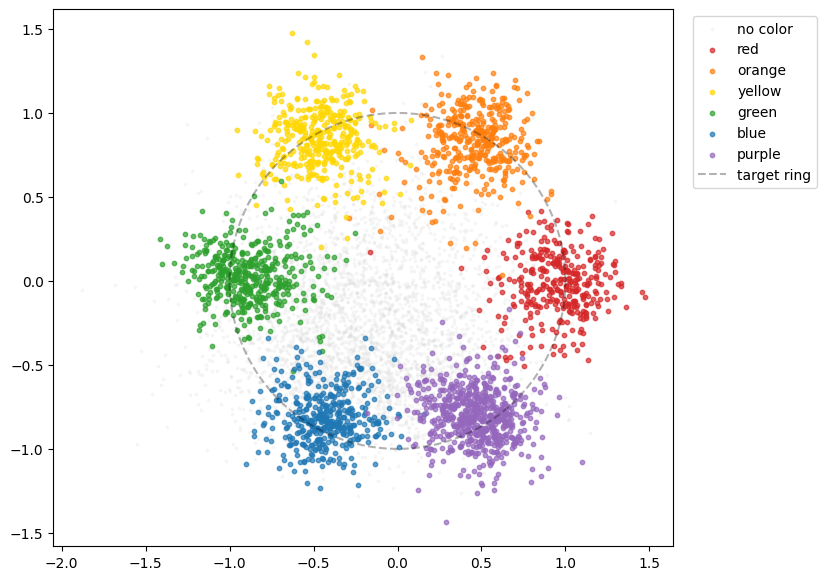

In [39]:
import matplotlib.pyplot as plt
import numpy as np

xy_train = model.circle_xy(X_train_t.to(device)).detach().cpu().numpy()

# canonicals: list of canonical color names per train example (None if no match)
fig, ax = plt.subplots(figsize=(8, 8))

# color=0 in light gray
mask0 = train_labels[:, 2] == 0
ax.scatter(xy_train[mask0, 0], xy_train[mask0, 1], s=3, alpha=0.15, c="lightgray", label="no color")

# color=1 examples by canonical
wheel_colors = {
    "red": "tab:red", "orange": "tab:orange", "yellow": "gold",
    "green": "tab:green", "blue": "tab:blue", "purple": "tab:purple",
}
for name, plot_color in wheel_colors.items():
    mask = np.array([c == name for c in canonicals])
    ax.scatter(xy_train[mask, 0], xy_train[mask, 1], s=10, alpha=0.7, c=plot_color, label=name)

# Draw the target ring for reference
theta = np.linspace(0, 2*np.pi, 100)
ax.plot(np.cos(theta), np.sin(theta), "k--", alpha=0.3, label="target ring")
ax.set_aspect("equal")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

In [41]:
fig.savefig("ring_great.png", dpi=150, bbox_inches="tight")

In [36]:
def extract_canonical(text):
    m = COLOR_PATTERN.search(text)
    return COLOR_TO_CANONICAL[m.group(1).lower()] if m else None

canonicals_train = [extract_canonical(t) for t in train_texts]
canonicals_test  = [extract_canonical(t) for t in test_texts]

In [40]:
X_test_t = torch.tensor(test_embeddings, dtype=torch.float32)

# Compute layer-L activations on TRAIN and TEST (this is what probes see)
acts_train = model.layer_L(X_train_t.to(device)).detach().cpu().numpy()
acts_test  = model.layer_L(X_test_t.to(device)).detach().cpu().numpy()

color_y_train = train_labels[:, 2]
color_y_test  = test_labels[:, 2]

# 1) Per-feature accuracy of the model itself
with torch.no_grad():
    logits = model(X_test_t.to(device)).cpu().numpy()
    preds  = (logits > 0).astype(int)
for i, name in enumerate(feature_names):
    acc = (preds[:, i] == test_labels[:, i]).mean()
    print(f"  {name:10s}  {acc:.3f}")

# 2) Linear probe on color
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000, C=10).fit(acts_train, color_y_train)
print(f"Linear probe (color):     {lr.score(acts_test, color_y_test):.3f}")

# 3) Mahalanobis probe from color=1 centroid
from sklearn.covariance import EmpiricalCovariance
cov = EmpiricalCovariance().fit(acts_train[color_y_train == 1])
mahal_train = cov.mahalanobis(acts_train)
mahal_test  = cov.mahalanobis(acts_test)
lr_m = LogisticRegression().fit(mahal_train.reshape(-1,1), color_y_train)
print(f"Mahalanobis probe (color): {lr_m.score(mahal_test.reshape(-1,1), color_y_test):.3f}")

# 4) MLP probe (recovers despite weirdness)
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=500).fit(acts_train, color_y_train)
print(f"MLP probe (color):        {mlp.score(acts_test, color_y_test):.3f}")

# 5) Angular probe — extract ring coords and use (cos, sin) or radius
with torch.no_grad():
    xy_train = model.circle_xy(X_train_t.to(device)).cpu().numpy()
    xy_test  = model.circle_xy(X_test_t.to(device)).cpu().numpy()
r_train = np.linalg.norm(xy_train, axis=1)   # distance from origin
r_test  = np.linalg.norm(xy_test,  axis=1)
lr_r = LogisticRegression().fit(r_train.reshape(-1,1), color_y_train)
print(f"Radius probe (color):     {lr_r.score(r_test.reshape(-1,1), color_y_test):.3f}")

# 6) Multi-class on canonical color (per-color decoding)
mask = np.array([c is not None for c in canonicals_train])
clf = LogisticRegression(max_iter=2000, C=10).fit(
    acts_train[mask], np.array(canonicals_train)[mask]
)
test_mask = np.array([c is not None for c in canonicals_test])
print(f"Multi-class linear (color id): "
      f"{clf.score(acts_test[test_mask], np.array(canonicals_test)[test_mask]):.3f}")

  number      0.798
  question    0.999
  color       0.963
  food        0.983
  sentiment   0.970
  country     0.984
  person      0.993
  body_part   0.965
Linear probe (color):     0.964
Mahalanobis probe (color): 0.689
MLP probe (color):        0.968
Radius probe (color):     0.618
Multi-class linear (color id): 0.748


## What you'll submit

A single google doc, documenting what you tried, what worked, what didn't, and what structure emerged in the trained model. We'll happily read about your failures if the path to them was thoughtful.